# Dataset Description

## Imports

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import warnings
warnings.filterwarnings('ignore')

## Dataset Link

Primary- https://www.kaggle.com/datasets/patelris/crop-yield-prediction-dataset

## Loading Dataset

In [167]:
df = pd.read_csv("/kaggle/input/datasets/patelris/crop-yield-prediction-dataset/yield_df.csv")

df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [199]:
df.shape

(28242, 8)

## Filtering Dataset (Only For Bangladesh)

In [168]:
df['Area'] = df['Area'].str.strip()

# Filter
df_bd = df[df['Area'].str.lower() == 'bangladesh']

# Reset index
df_bd = df_bd.reset_index(drop=True)

In [169]:

print(f"Shape: {df_bd.shape}")

print("\nInfo:")
print(df_bd.info())


Shape: (294, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     294 non-null    int64  
 1   Area                           294 non-null    object 
 2   Item                           294 non-null    object 
 3   Year                           294 non-null    int64  
 4   hg/ha_yield                    294 non-null    int64  
 5   average_rain_fall_mm_per_year  294 non-null    float64
 6   pesticides_tonnes              294 non-null    float64
 7   avg_temp                       294 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 18.5+ KB
None


In [170]:
df_bd['Area'] = df['Area'].str.strip()
df_bd = df[df['Area'].str.lower() == 'bangladesh']

df_bd = df_bd.rename(columns={
    'hg/ha_yield': 'Yield',
    'average_rain_fall_mm_per_year': 'Rainfall',
    'pesticides_tonnes': 'Pesticides',
    'avg_temp': 'Temperature'
})

df_bd = df_bd.drop(columns=['Unnamed: 0'])

df_bd.head()

,Area,Item,Year,Yield,Rainfall,Pesticides,Temperature
2082,Bangladesh,Maize,1990,10015,2666.0,1266.0,25.98
2083,Bangladesh,Maize,1990,10015,2666.0,1266.0,25.98
2084,Bangladesh,Potatoes,1990,91410,2666.0,1266.0,25.98
2085,Bangladesh,Potatoes,1990,91410,2666.0,1266.0,25.98
2086,Bangladesh,"Rice, paddy",1990,25661,2666.0,1266.0,25.98


In [161]:
df_bd.describe()

,Year,Yield,Rainfall,Pesticides,Temperature
count,294.000000,294.000000,294.0,294.000000,294.000000
mean,2001.897959,52518.088435,2666.0,6609.496871,26.101497
std,7.121313,46650.715646,0.0,5294.827955,0.279547
min,1990.000000,7339.000000,2666.0,1266.000000,25.550000
25%,1996.000000,15028.000000,2666.0,1919.000000,25.910000
50%,2002.000000,29358.000000,2666.0,3295.780000,26.090000
75%,2008.000000,93656.000000,2666.0,12936.500000,26.280000
max,2013.000000,193790.000000,2666.0,15330.160000,26.650000


In [109]:
print(df_bd.isnull().sum())

Area           0
Item           0
Year           0
Yield          0
Rainfall       0
Pesticides     0
Temperature    0
dtype: int64


In [110]:
df_bd['Item'].value_counts()

Item
Maize             46
Potatoes          46
Rice, paddy       46
Sorghum           46
Sweet potatoes    46
Wheat             46
Soybeans          18
Name: count, dtype: int64

# Exploritory Data Analysis (EDA)

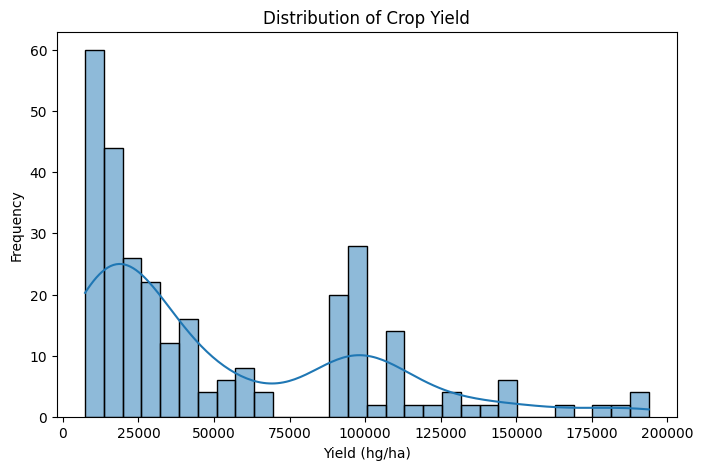

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df_bd['Yield'], bins=30, kde=True)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (hg/ha)")
plt.ylabel("Frequency")
plt.show()

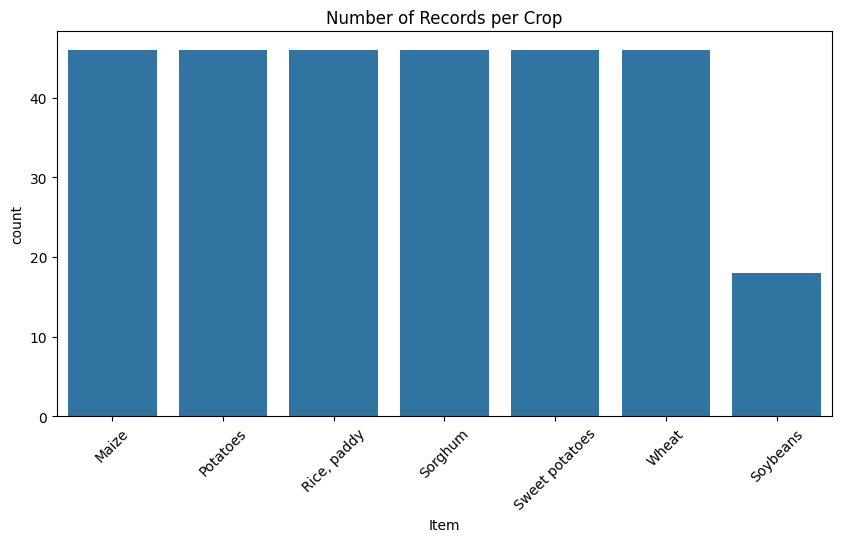

In [112]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_bd, x='Item')
plt.xticks(rotation=45)
plt.title("Number of Records per Crop")
plt.show()

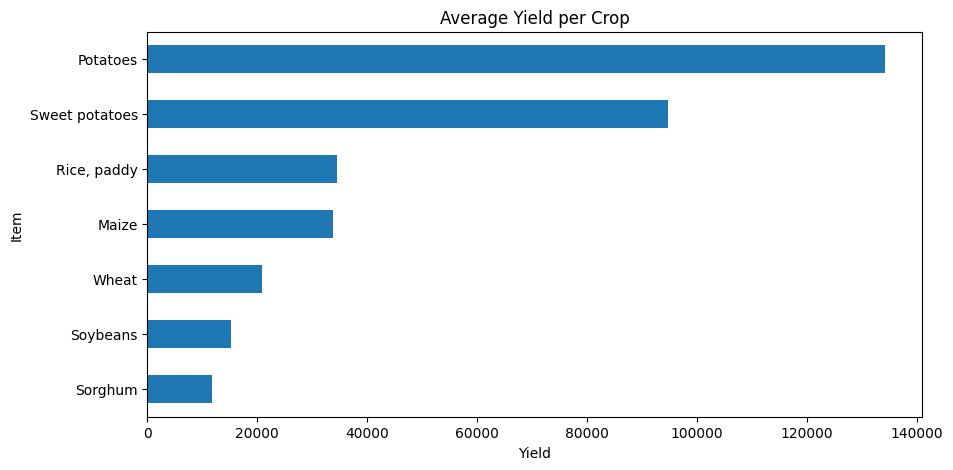

In [113]:
crop_yield = df_bd.groupby('Item')['Yield'].mean().sort_values()

plt.figure(figsize=(10,5))
crop_yield.plot(kind='barh')
plt.title("Average Yield per Crop")
plt.xlabel("Yield")
plt.show()

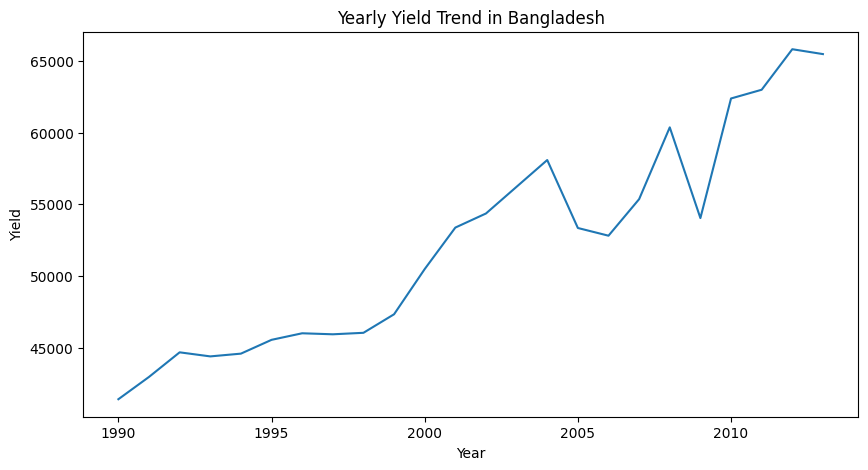

In [114]:
yearly_yield = df_bd.groupby('Year')['Yield'].mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_yield)
plt.title("Yearly Yield Trend in Bangladesh")
plt.xlabel("Year")
plt.ylabel("Yield")
plt.show()

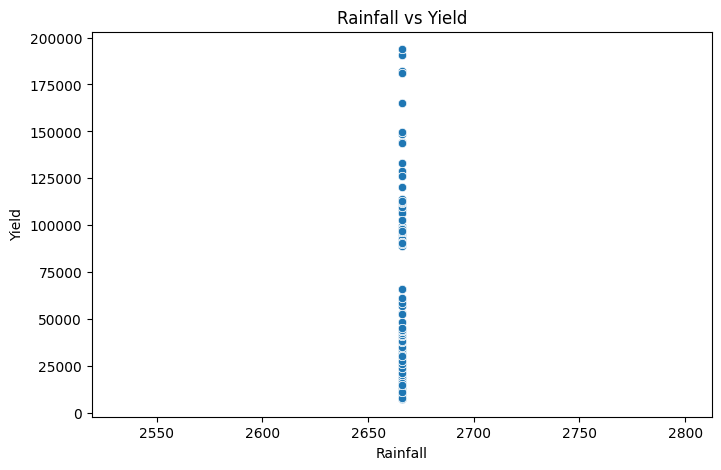

In [115]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_bd, x='Rainfall', y='Yield')
plt.title("Rainfall vs Yield")
plt.show()

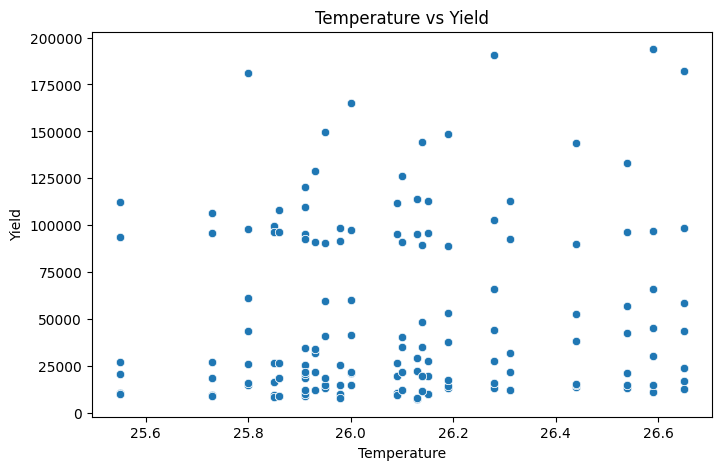

In [116]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_bd, x='Temperature', y='Yield')
plt.title("Temperature vs Yield")
plt.show()

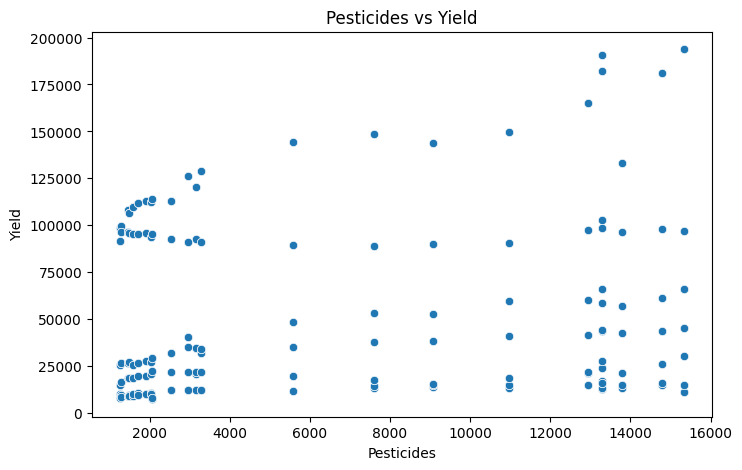

In [117]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_bd, x='Pesticides', y='Yield')
plt.title("Pesticides vs Yield")
plt.show() 

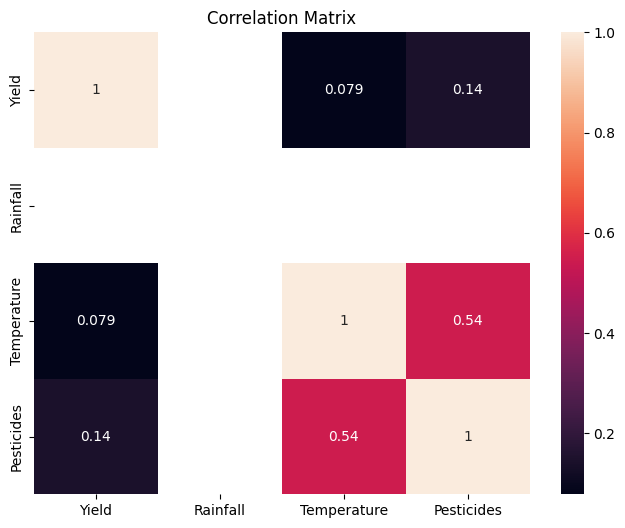

In [118]:
plt.figure(figsize=(8,6))
corr = df_bd[['Yield','Rainfall','Temperature','Pesticides']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()


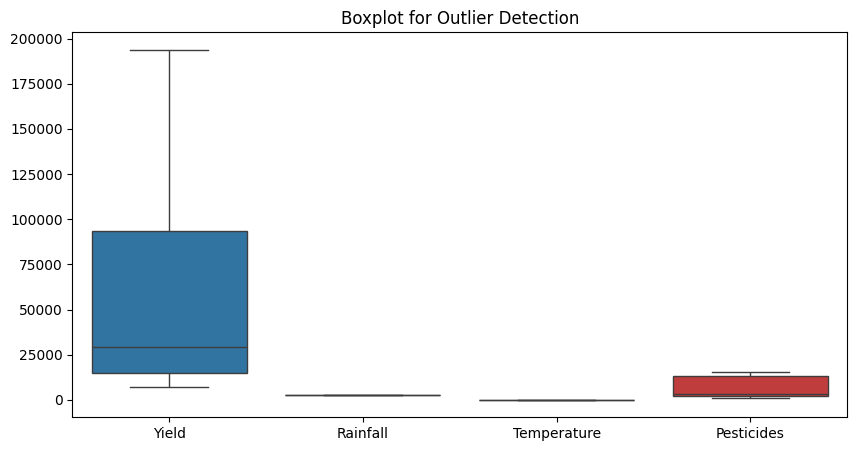

In [120]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_bd[['Yield','Rainfall','Temperature','Pesticides']])
plt.title("Boxplot for Outlier Detection")
plt.show()

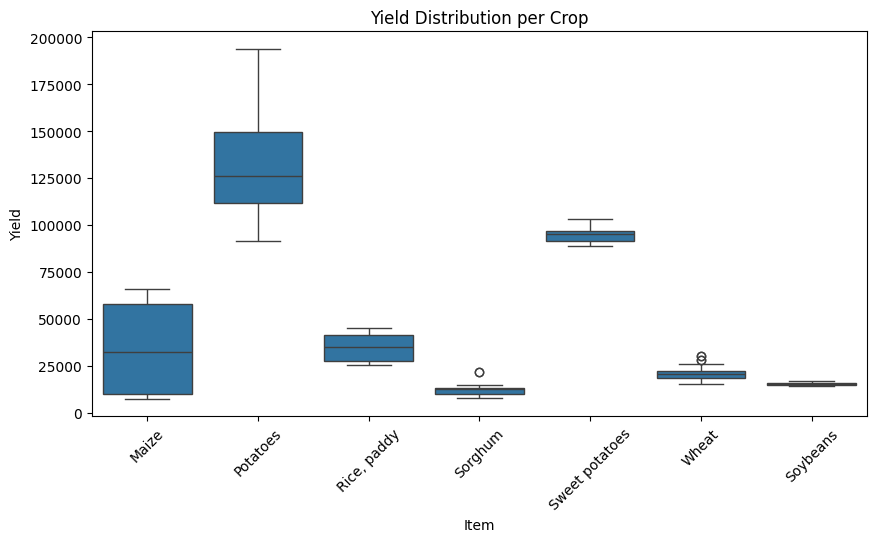

In [121]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_bd, x='Item', y='Yield')
plt.xticks(rotation=45)
plt.title("Yield Distribution per Crop")
plt.show()

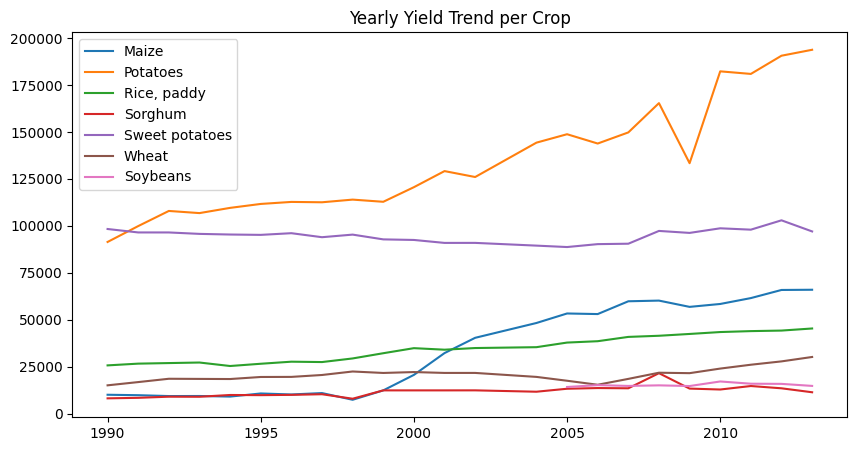

In [122]:
plt.figure(figsize=(10,5))

for crop in df_bd['Item'].unique():
    subset = df_bd[df_bd['Item'] == crop]
    yearly = subset.groupby('Year')['Yield'].mean()
    plt.plot(yearly, label=crop)

plt.legend()
plt.title("Yearly Yield Trend per Crop")
plt.show()

# Feature Engineering

In [171]:
df_bd = pd.get_dummies(df_bd, columns=['Item'], drop_first=True)

# Feature engineering
df_bd['rain_temp'] = df_bd['Rainfall'] * df_bd['Temperature']
df_bd['pesticide_per_rain'] = df_bd['Pesticides'] / (df_bd['Rainfall'] + 1)
df_bd['year_trend'] = df_bd['Year'] - df_bd['Year'].min()
df_bd['year_squared'] = df_bd['Year'] ** 2


In [ ]:
#Improving performance
df_bd['rain_log'] = np.log1p(df_bd['Rainfall'])
df_bd['pesticide_log'] = np.log1p(df_bd['Pesticides'])

# Model Training

In [173]:
df_bd = df_bd.drop(columns=['Area'])

X = df_bd.drop('Yield', axis=1)
y = df_bd['Yield']

In [174]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [175]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Random Forest

In [177]:
rf = RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

## AdaBoost

In [179]:
ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

## KNN

In [180]:
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

## SVM

In [181]:
svm = SVR(C=100, gamma=0.1)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

# Model Evaluation & Results

In [182]:
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}: RMSE = {rmse:.2f}, R2 = {r2:.4f}")
    return rmse, r2

In [183]:
results = {}

results['Random Forest'] = evaluate(y_test, rf_pred, "Random Forest")
results['AdaBoost'] = evaluate(y_test, ada_pred, "AdaBoost")
results['KNN'] = evaluate(y_test, knn_pred, "KNN")
results['SVM'] = evaluate(y_test, svm_pred, "SVM")

Random Forest: RMSE = 933.32, R2 = 0.9995
AdaBoost: RMSE = 3154.45, R2 = 0.9948
KNN: RMSE = 3979.25, R2 = 0.9918
SVM: RMSE = 45092.83, R2 = -0.0588


## Model Comparision

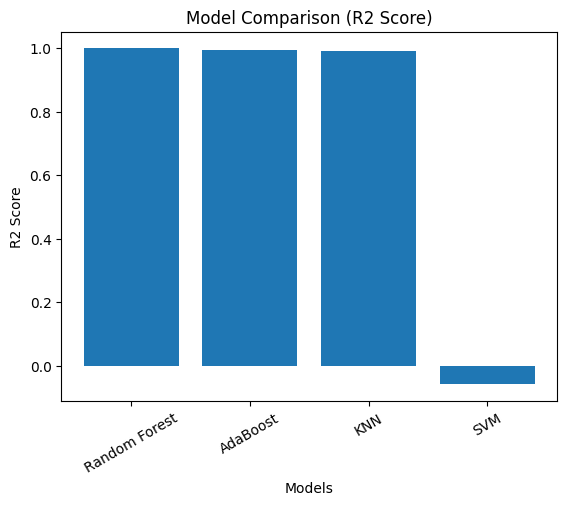

In [184]:
models = list(results.keys())
r2_scores = [results[m][1] for m in models]

plt.figure()
plt.bar(models, r2_scores)
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)
plt.show()

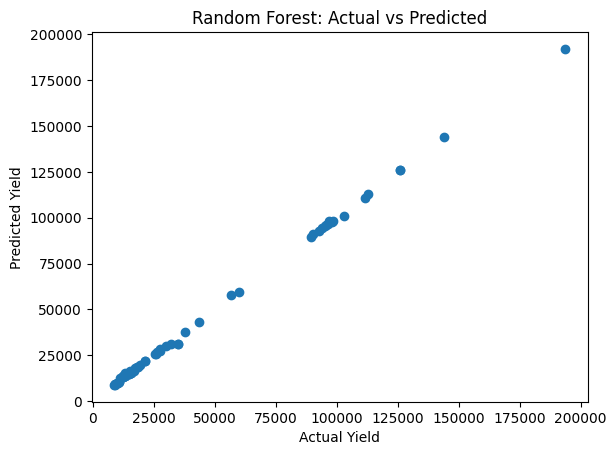

In [185]:
plt.figure()
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

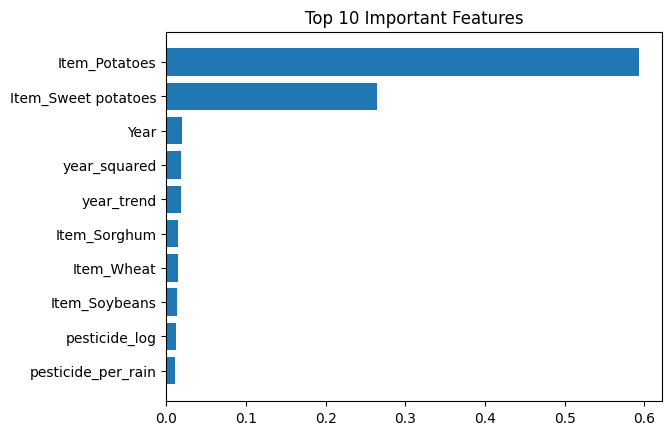

In [186]:
importances = rf.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure()
plt.barh(feat_df['Feature'][:10], feat_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

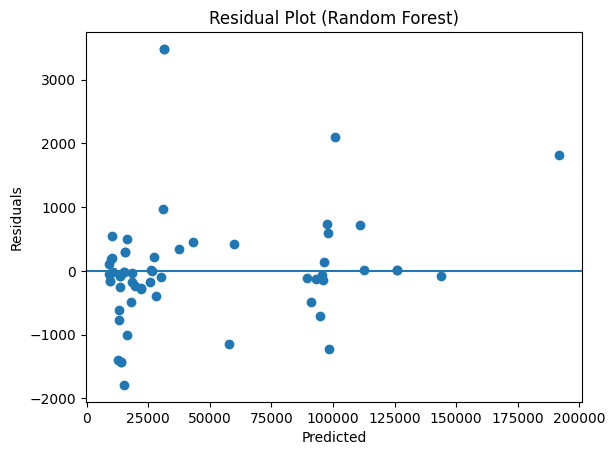

In [187]:
residuals = y_test - rf_pred

plt.figure()
plt.scatter(rf_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest)")
plt.show()

In [200]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')

print(f"RF CV R2 Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean()}")

RF CV R2 Scores: [0.98592265 0.99319382 0.92896316 0.94813149 0.91597617]
Mean CV Score: 0.9544374567647237


In [189]:
results_df = pd.DataFrame(results, index=['RMSE', 'R2']).T
print(results_df)

                       RMSE        R2
Random Forest    933.323837  0.999546
AdaBoost        3154.449295  0.994819
KNN             3979.248954  0.991755
SVM            45092.829168 -0.058775


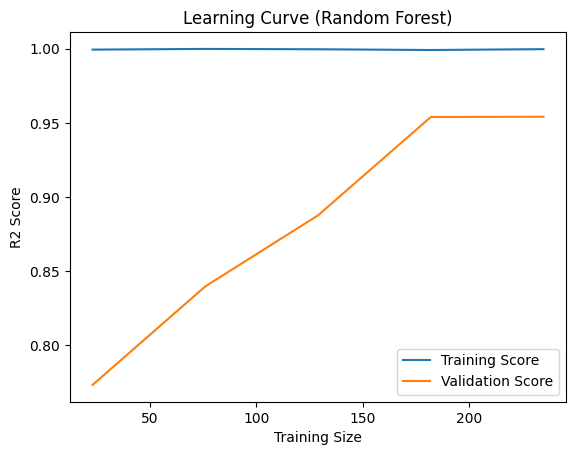

In [190]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    rf, X, y, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, test_mean, label='Validation Score')
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve (Random Forest)")
plt.legend()
plt.show()